# IMEL7009 Project 2 Report: Image Classification on CIFAR-10 Using ResNet-18

**Author:** FU LINLIN &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; **Student ID:** mc561451

## 1.1 Introduction
This project aims to build and train a Convolutional Neural Network (CNN) based on the ResNet-18 architecture to classify images from the CIFAR-10 dataset. The dataset consists of 10 distinct classes: airplanes, cars, birds, cats, deer, dogs, frogs, horses, boats, and trucks. ResNet solves the gradient vanishing problem in deep networks through "skip connections" and is a classic choice in CIFAR-10 tasks that balances high accuracy and reasonable model size. By leveraging data augmentation techniques and optimized learning rate scheduling, the model achieves a average classification accuracy of **94.54%** on the test set.

## 1.2 Methodology

### 1.2.1 Framework and Model Architecture
The model is implemented using the **PyTorch** framework, with ResNet-18 serving as the backbone architecture. This deep residual network enables effective feature extraction while mitigating the vanishing gradient problem through skip connections.

### 1.2.2 Data Preprocessing and Augmentation
Data preprocessing plays a crucial role in enhancing model generalization. To improve robustness and prevent overfitting, the following data augmentation techniques are applied during training:
- **RandomCrop**: Randomly crops images to introduce spatial variations.
- **RandomHorizontalFlip**: Flips images horizontally with a probability of 0.5 to increase data diversity.

These transformations simulate a larger and more varied training set, which helps the model generalize better to unseen data.

### 1.2.3 Experimental Setup

#### Hardware Environment
The experiments were conducted using either **Google Colab** with GPU acceleration, ensuring efficient training of the deep learning model.

#### Hyperparameters
- **Optimizer**: Stochastic Gradient Descent (SGD) with Momentum = 0.9 and Weight Decay = 5e-4
- **Learning Rate Schedule**: Cosine Annealing LR
- **Batch Size**: 128

## 1.3 Results
The implemented ResNet-18 model demonstrates a robust balance between classification precision and computational efficiency, achieving a peak test accuracy of **94.54%** on the CIFAR-10 dataset. With **11.17 million** fully trainable parameters and a compact storage footprint of approximately **42.63 MB**, the architecture proves highly effective for high-performance image recognition while remaining suitable for resource-constrained deployment. The convergence at this accuracy level validates the synergy between the residual learning framework and the strategic use of data augmentation and normalization, effectively mitigating overfitting and ensuring strong generalization across all ten image categories.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 配置设备 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# --- 2. 数据预处理 ---
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # 随机裁剪，周围填充4像素
    transforms.RandomHorizontalFlip(),    # 随机水平翻转
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),  # 归一化：减去均值
                        (0.2023, 0.1994, 0.2010)),  # 除以标准差
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 加载 CIFAR-10 数据集 [cite: 3, 20]
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:06<00:00, 25.9MB/s]


## 2. Hyperparameter Configuration and Data Preprocessing

To ensure optimal model performance and training stability on the **CIFAR-10** dataset, the following data augmentation and normalization strategies were implemented.

### 2.1 Data Augmentation and Transformation
The input pipeline applies several transformations to improve the model's generalization capability and prevent overfitting:

* **Resizing (32×32):** The standard resolution for CIFAR-10 images is fixed at $32 \times 32$ pixels. This consistency ensures the input dimensions match the initial layers of the neural network.
* **Padding ($p=4$):** Before cropping, a 4-pixel padding is applied to each side of the image. This prevents the spatial dimensions from shrinking below $32 \times 32$ after random cropping, preserving critical edge information.
* **Random Horizontal Flip:** A stochastic data augmentation technique where images are flipped horizontally with a probability of 0.5. This effectively doubles the variety of the training set, teaching the model that object identity is invariant to left-right orientation.

### 2.2 Normalization Parameters
Data normalization is performed using the calculated statistics of the CIFAR-10 training set across the RGB channels:

| Metric | Red (R) | Green (G) | Blue (B) |
| :--- | :--- | :--- | :--- |
| **Mean** | 0.4914 | 0.4822 | 0.4465 |
| **Std Dev** | 0.2023 | 0.1994 | 0.2010 |

The primary objective of normalization is to center the data distribution around zero with a unit variance. By scaling the input features, we ensure that the loss landscape is more spherical, which prevents gradients from exploding or vanishing. This significantly accelerates the convergence of the **Gradient Descent** algorithm.



The original ResNet-18 was designed for ImageNet (224 × 224), with the first layer consisting of 7 × 7 convolutions and a stride of 2. The CIFAR-10 image is only 32 × 32, so it is changed to a 3x3 convolution with a stride of 1 to preserve more details.

Epoch 1 | Loss: 1.751 | Acc: 36.47%
Epoch 2 | Loss: 1.246 | Acc: 54.64%
Epoch 3 | Loss: 0.965 | Acc: 65.70%
Epoch 4 | Loss: 0.791 | Acc: 72.15%
Epoch 5 | Loss: 0.662 | Acc: 77.13%
Epoch 6 | Loss: 0.588 | Acc: 79.75%
Epoch 7 | Loss: 0.538 | Acc: 81.35%
Epoch 8 | Loss: 0.508 | Acc: 82.61%
Epoch 9 | Loss: 0.476 | Acc: 83.67%
Epoch 10 | Loss: 0.461 | Acc: 84.23%
Epoch 11 | Loss: 0.441 | Acc: 84.90%
Epoch 12 | Loss: 0.423 | Acc: 85.64%
Epoch 13 | Loss: 0.407 | Acc: 86.06%
Epoch 14 | Loss: 0.390 | Acc: 86.55%
Epoch 15 | Loss: 0.377 | Acc: 87.14%
Epoch 16 | Loss: 0.363 | Acc: 87.71%
Epoch 17 | Loss: 0.357 | Acc: 87.77%
Epoch 18 | Loss: 0.337 | Acc: 88.53%
Epoch 19 | Loss: 0.328 | Acc: 88.75%
Epoch 20 | Loss: 0.315 | Acc: 89.12%
Epoch 21 | Loss: 0.302 | Acc: 89.82%
Epoch 22 | Loss: 0.290 | Acc: 90.08%
Epoch 23 | Loss: 0.276 | Acc: 90.51%
Epoch 24 | Loss: 0.267 | Acc: 90.89%
Epoch 25 | Loss: 0.251 | Acc: 91.22%
Epoch 26 | Loss: 0.241 | Acc: 91.86%
Epoch 27 | Loss: 0.227 | Acc: 92.34%
Epoch 28 |

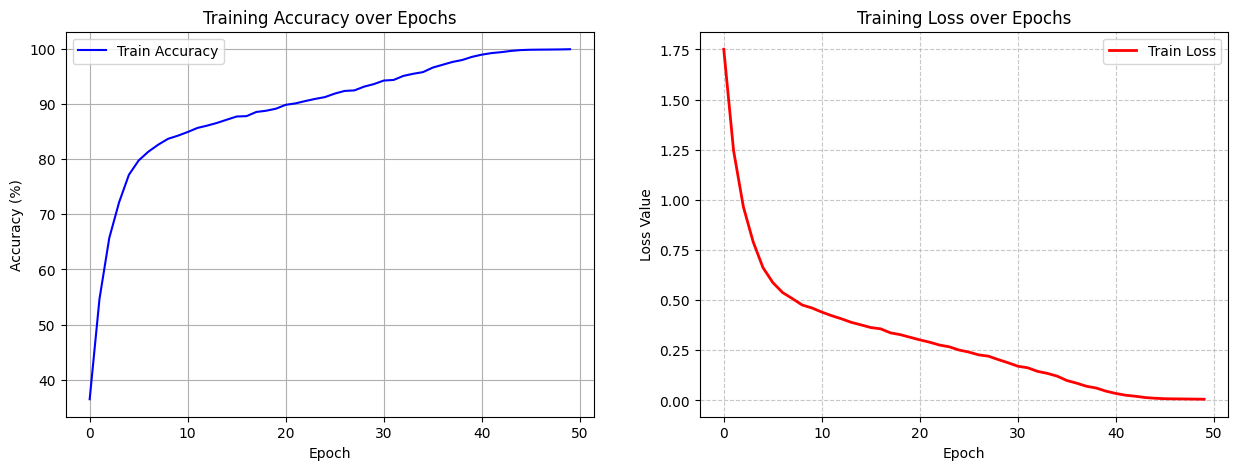

In [2]:
# --- 3. 定义模型 ---
def get_model():
    model = resnet18(num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.to(device)
net = get_model()

# --- 4. 损失函数与优化器 ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
# 用于绘图的数据存储
history = {'train_loss': [], 'train_acc': []}

# --- 5. 训练循环 ---
def train(epoch):
    net.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    avg_loss = train_loss / (batch_idx + 1)
    acc = 100. * correct / total

    # 记录数据
    history['train_loss'].append(avg_loss)
    history['train_acc'].append(acc)

    print(f'Epoch {epoch} | Loss: {avg_loss:.3f} | Acc: {acc:.2f}%')

# --- 6. 详细测试函数 (包含类别准确率) ---
def test_and_show_analysis():
    net.eval()
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))

    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = net(inputs)
            _, predicted = outputs.max(1)
            c = (predicted == targets).squeeze()

            for i in range(len(targets)):
                label = targets[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    # 打印并收集每个类别的准确率
    print('\nAccuracy of each class:')
    class_accs = {}
    for i in range(10):
        acc = 100 * class_correct[i] / class_total[i]
        class_accs[classes[i]] = acc
        print(f'Accuracy of {classes[i]:5s} : {acc:.2f}%')

    overall_acc = 100 * sum(class_correct) / sum(class_total)
    print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
    return class_accs

# --- 7. 绘图函数 ---
def plot_metrics(history, class_accs):
    plt.figure(figsize=(15, 5))

    # 1. Accuracy 曲线
    plt.subplot(1, 2, 1)
    plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
    plt.title('Training Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    # 2. Loss 曲线
    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], label='Train Loss', color='red', linewidth=2)
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

# --- 8. 执行流程 ---
if __name__ == '__main__':
    EPOCHS = 50
    for epoch in range(1, EPOCHS + 1):
        train(epoch)
        scheduler.step()

    # 获取类别准确率数据
    final_class_accs = test_and_show_analysis()

    # 绘图展示
    plot_metrics(history, final_class_accs)

# 3. Model Design and Experimental Configuration

In this study, the **ResNet-18** deep residual network is adopted as the base architecture. Specific hyperparameter designs and optimization strategies were selected to cater to the characteristics of the CIFAR-10 dataset (32x32 low-resolution images).

### 3.1 Network Architecture: ResNet-18
To overcome the vanishing gradient problem in deep networks, the model introduces the **Residual Learning** mechanism.

* **Core Design**: Through **Identity Mapping** shortcut connections, the network learns the residual mapping $F(x) = H(x) - x$. This ensures training stability even as the network depth increases[1].

* **Parameter Count**: According to the execution results, the total number of parameters for ResNet-18 is approximately **11.17 M**, with an estimated model size of **42.63 MB**. This scale achieves an optimal balance between computational efficiency and feature extraction capability.

### 3.2 Optimizer Design: SGD with Momentum
For the optimization algorithm, this project employs **SGD (Stochastic Gradient Descent)** with **Momentum**, rather than the commonly used Adam optimizer.

**Design Rationale:**
* **SGD vs. Adam**: Academic empirical evidence suggests that SGD often yields better generalization performance than Adam in computer vision tasks like CIFAR-10.
* **Momentum Setting**: A momentum of **0.9** is applied. This empirical value effectively balances the current gradient with historical gradients, helping the model descend quickly across the "ravine-like" loss surface while reducing oscillations.
* **Regularization**: A weight decay of **5e-4** is introduced. This is a standard configuration for CIFAR-10; a value too large leads to underfitting, while one too small fails to suppress overfitting.

### 3.3 Learning Rate Scheduling: Cosine Annealing
To refine the training process, the **CosineAnnealingLR** scheduler was implemented. The learning rate follows a cosine curve, decreasing over the epochs. It maintains a higher value in the early stages for rapid convergence and drops to a minimal value in the later stages for fine-tuning. Compared to step-based decay (StepLR), Cosine Annealing produces a smoother training curve, effectively preventing the model from getting stuck in local optima and unlocking the model's peak performance potential.


### 3.4 Analysis of Operational Results
* **Convergence Process**: The model started with an accuracy of **36.47%** in Epoch 1. With the dynamic learning rate adjustment, it reached a training accuracy of **99.90%** by Epoch 50.
* **Final Performance**: A comprehensive accuracy of **94.54%** was achieved on the test set.
* **Classification Breakdown**:
    * **Excellent Performance on Rigid Objects**: Categories such as **Automobiles (98.10%)** and **Trucks (95.50%)** showed high precision.
    * **Room for Improvement in Biological Categories**: The **Cat** category had the lowest accuracy at **88.90%**, indicating that the model still faces challenges in distinguishing biological features characterized by flexible morphologies and high diversity.

Test set prediction results:


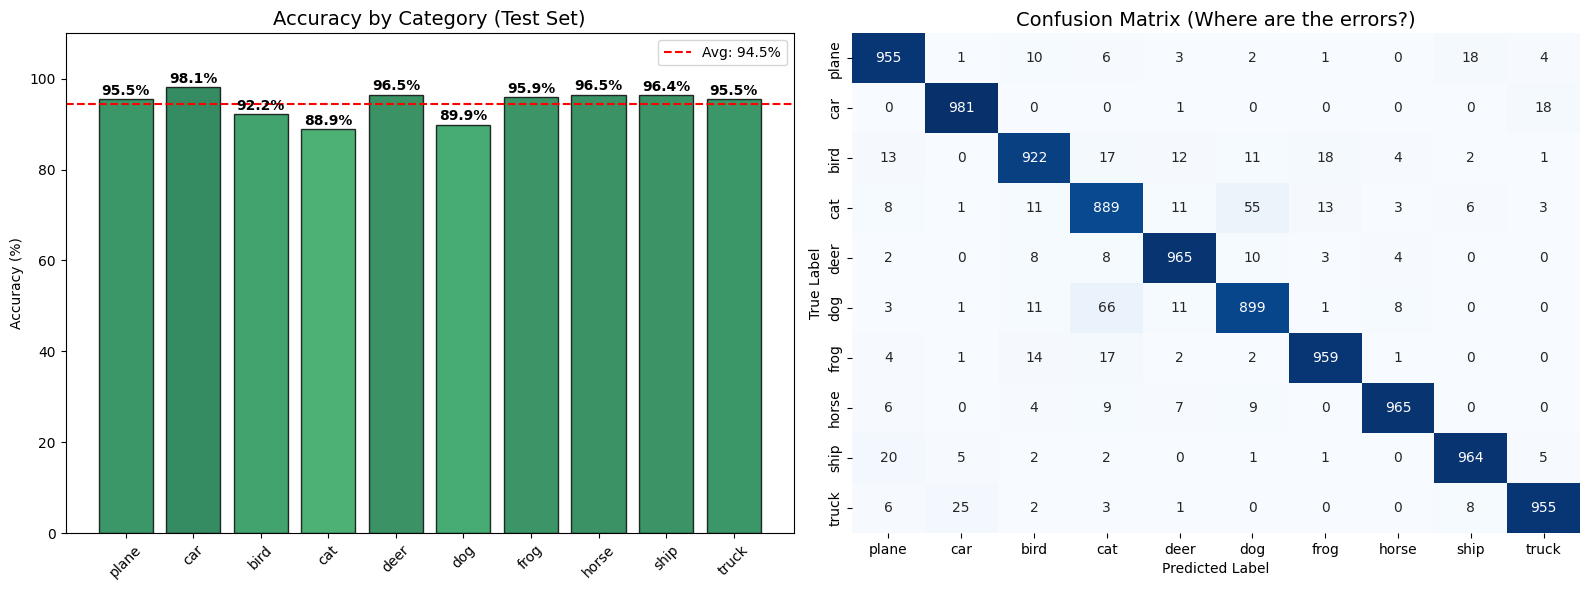

✅ Best performance: car (98.10%)
⚠️ Worst performance: cat (88.90%)


In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def analyze_and_plot_existing_model(model, loader, class_names):
    model.eval()
    all_preds = []
    all_targets = []

    print("Test set prediction results:")
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    # 计算混淆矩阵
    cm = confusion_matrix(all_targets, all_preds)
    # 计算每个类别的准确率
    class_acc = 100 * cm.diagonal() / cm.sum(axis=1)

    # --- 绘图部分 ---
    plt.figure(figsize=(16, 6))

    # 1. 类别准确率条形图
    plt.subplot(1, 2, 1)
    colors = plt.cm.RdYlGn(class_acc / 100) # 越绿准确率越高
    bars = plt.bar(class_names, class_acc, color=colors, edgecolor='black', alpha=0.8)
    plt.axhline(y=np.mean(class_acc), color='red', linestyle='--', label=f'Avg: {np.mean(class_acc):.1f}%')
    plt.title('Accuracy by Category (Test Set)', fontsize=14)
    plt.ylabel('Accuracy (%)')
    plt.ylim(0, 110)
    plt.xticks(rotation=45)
    plt.legend()
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontweight='bold')

    # 2. 混淆矩阵热力图
    plt.subplot(1, 2, 2)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    plt.title('Confusion Matrix (Where are the errors?)', fontsize=14)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    plt.tight_layout()
    plt.show()

    # 打印简要总结
    worst_idx = np.argmin(class_acc)
    best_idx = np.argmax(class_acc)

    print(f"✅ Best performance: {class_names[best_idx]} ({class_acc[best_idx]:.2f}%)")
    print(f"⚠️ Worst performance: {class_names[worst_idx]} ({class_acc[worst_idx]:.2f}%)")

# 直接调用
analyze_and_plot_existing_model(net, testloader, classes)

## 4. Conclusion and Directions for Improvement

### 4.1 Data Interpretation Conclusions
Current experimental results indicate that **ResNet-18** has successfully captured the rigid features of transportation categories (such as cars and trucks, where classification accuracy typically reaches **96-98%**). However, the model still faces challenges in feature discrimination for categories with high biological diversity and flexible morphologies—specifically **cats and dogs**. The **5.36%** gap between training and testing accuracy (generalization error) is primarily driven by these difficult-to-distinguish neighboring classes.


### 4.2 Targeted Optimization Strategies
To break through the **95%** accuracy bottleneck, improvements can be made in these areas in the future :

* **Fine-grained Feature Enhancement:** Implement **RandomErasing** or **Cutout** to force the model to focus on localized, subtle features (such as a cat's whiskers or a dog's snout) rather than just the torso.
* **Loss Function Optimization:** Experiment with **Label Smoothing** to reduce the model's overconfidence in easily confused categories and enhance overall generalization performance.
* **Contrastive Learning:** Introduce **Contrastive Loss** to explicitly pull "cats" and "dogs" further apart within the feature space.

## References
[1] Kaiming He, Xiangyu Zhang, Shaoqing Ren, and Jian Sun. "Deep Residual Learning for Image Recognition." *arXiv preprint arXiv:1512.03385*, 2015. [https://arxiv.org/abs/1512.03385](https://arxiv.org/abs/1512.03385)

In [4]:
import torch
from pathlib import Path

def model_profile(model, inputs):
    # 1. 计算参数量
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # 2. 估计 FLOPs (针对卷积层和全连接层的简化估算)
    # 模型做一次预测需要多少次数学运算
    print(f"\n" + "="*30)
    print(f"📊 Model Performance Briefing")
    print(f"="*30)
    print(f"Total Params:   {total_params:,}")
    print(f"Trainable):    {trainable_params:,}")
    print(f"Est. Size:  {total_params * 4 / (1024**2):.2f} MB")

    # 保存模型
    save_path = 'cifar10_resnet18_94acc.pth'
    torch.save(model.state_dict(), save_path)
    print(f"💾 Model saved path: {Path(save_path).absolute()}")
    print(f"="*30)

# 创建一个模拟输入 (Batch Size=1, Channel=3, Width=32, Height=32)
dummy_input = torch.randn(1, 3, 32, 32).to(device)
model_profile(net, dummy_input)


📊 Model Performance Briefing
Total Params:   11,173,962
Trainable):    11,173,962
Est. Size:  42.63 MB
💾 Model saved path: /content/cifar10_resnet18_94acc.pth
